# Magnitude Schechter

In [1]:
import numpy as np
import astropy.units as u
from astropy.coordinates import SkyCoord
import healpy as hp
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.integrate import quad

from iminuit import Minuit
from iminuit.cost import LeastSquares

from simulMap import *

# Set random seed for reproducibility
#np.random.seed(42)

In [2]:
#resolution:
nside = 64
npix = hp.nside2npix(nside)
print("Number of pixels = {}".format(npix))

Number of pixels = 49152


## Magnitude sampling

In [9]:
def absMag2lum(M, M_star):
    """Return the luminosity frome the absolute magnitude M and a reference  absolute magnitude M_sar."""
    return 10**(0.4 * (M_star - M))


def proba_schechter_mag(M, M_star, alpha):
    """Compute the relative probability of a magnitude M.
    M_star is the caracteristic magnitude of Schechter's luminosity function."""
    L_ratio = absMag2lum(M, M_star) #Conversion magnitude -> relative luminosity L/L*
    return (L_ratio**alpha) * np.exp(-L_ratio)


def generate_schechter_magnitudes(N, M_min=-23, M_max=-15, M_star=-20.44, alpha=-1.1):
    """Generate N randomized absolute magnitudes, by using a reject test and Schechter's law."""
    magnitudes = []
    while len(magnitudes) < N:
        M_test = np.random.uniform(M_min, M_max)
        p_test = np.random.uniform(0, 1) #Probability for rejet test
        if p_test < proba_schechter_mag(M_test, M_star, alpha): magnitudes.append(M_test)         
    return np.array(magnitudes)


def get_dL(zi, H0=67.4, Om=0.315, Ol=0.685, c=3e8):
    '''Compute the luminosity distance depending on the redshift z, the Hubble constant H0, the cosmological parameters Om and Ol, and the speed of ligt c.'''
    inv_Ez = lambda zp: 1.0 / np.sqrt(Om * (1 + zp)**3 + Ol)
    integral, _ = quad(inv_Ez, 0, zi)
    return (c / H0) * (1 + zi) * integral


def generate_magLum(N, z_min=0.01, z_max=3.0, M_min=-23, M_max=-15, M_star=-20.44, alpha=-1.1, **kwargs):
    #Cosmological Parameters  (Planck 2018):
    H0 = kwargs.get('H0', 67.4)
    Om = kwargs.get('Om', 0.315)
    Ol = kwargs.get('Ol', 0.685)
    c = kwargs.get('c', 3e5) #speed of ligt in km/s (because H0 is in Km/s/Mpc)
    M_sun = kwargs.get('M_sun', 4.83) #Absolute magnitude of Sun
    
    z = np.random.uniform(z_min, z_max, N) #Redshift
    dL_mpc = np.array([get_dL(zi, H0, Om, Ol, c) for zi in z]) #luminosity distance in Mpc
    M = generate_schechter_magnitudes(N, M_min, M_max, M_star, alpha) #Absolute magnitudes
    m = M + 5*np.log10(dL_mpc) + 25 #Aparent magnitudes
    L = absMag2lum(M, M_sun) #luminosities
    return z, m, M, L, dL_mpc

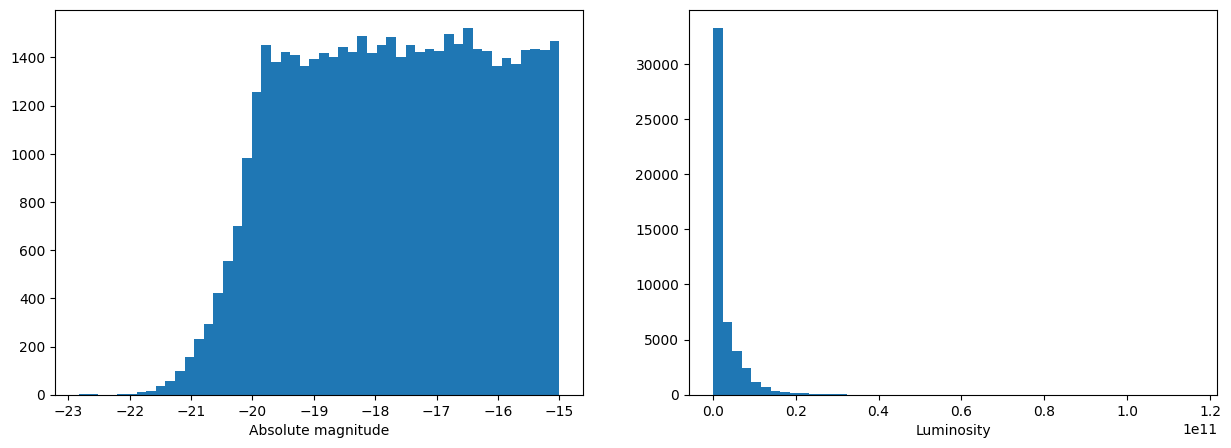

In [4]:
z, m, M, L, dL_mpc = generate_magLum(npix)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
get_hist(M, xlabel='Absolute magnitude', bins=50, figax=(fig, ax[0]))
get_hist(L, xlabel='Luminosity', bins=50, figax=(fig, ax[1]));

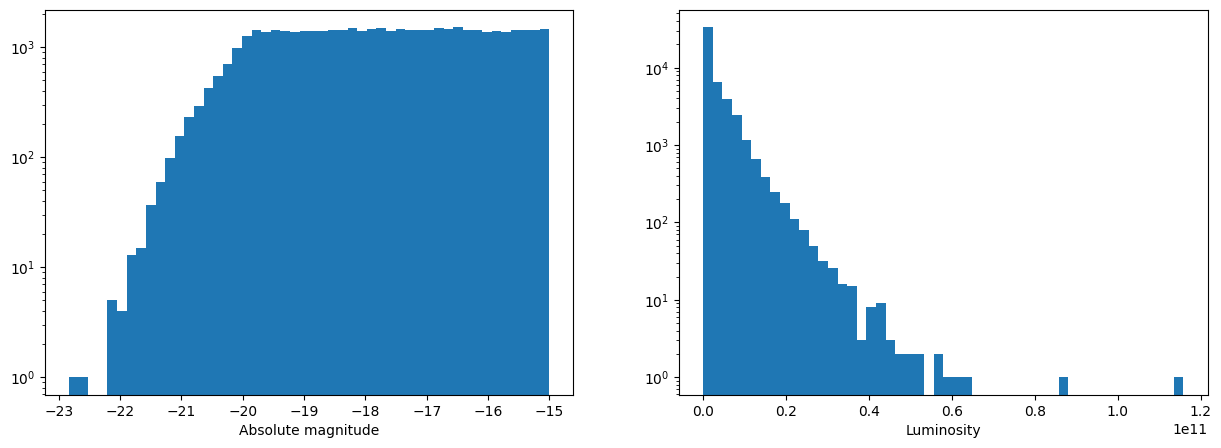

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
get_hist(M, xlabel='Absolute magnitude', bins=50, figax=(fig, ax[0]))
get_hist(L, xlabel='Luminosity', bins=50, figax=(fig, ax[1]))
ax[0].set_yscale('log')
ax[1].set_yscale('log');

## Luminosity sampling

### Linear space:

In [3]:
def sample_truncated_power_law(alpha, xmin, xmax, size=None):
    """
    Sample from a truncated power-law distribution p(x) ∝ x^alpha
    for xmin <= x <= xmax, with alpha < -1.

    Parameters:
        alpha (float): exponent (must be < -1)
        xmin (float): lower bound (> 0)
        xmax (float): upper bound (> xmin)
        size (int): number of samples

    Returns:
        numpy array of samples
    """
    if alpha == -1:
        raise ValueError("alpha = -1 requires a different (logarithmic) treatment")

    # Generate uniform random numbers
    u = np.random.uniform(0, 1, size)

    # Inverse CDF
    exponent = alpha + 1
    xmin_exp = xmin ** exponent
    xmax_exp = xmax ** exponent

    samples = (u * (xmax_exp - xmin_exp) + xmin_exp) ** (1 / exponent)

    return samples

In [65]:
def proba_schechter_lum(L, L_star, alpha, phi_star=1):
        return phi_star * np.power(L/L_star, alpha) * np.exp(-L/L_star)


def generate_schechter_lum(n_samples, L_star, alpha, L_min, L_max, phi_star=1):
    """Generate N randomized luminosities, by using a reject test and Schechter's law."""
    samples = []
    reject = 0 #to count the number of rejects
    f_max = proba_schechter_lum(L_min, L_star, alpha, phi_star) # The maximum value of the function on [L_min, L_max] is often at L_min if alpha < -1
    while len(samples) < n_samples:
        L_cand = sample_truncated_power_law(alpha, L_min, L_max)
        p_test = np.random.uniform(0, L_cand**alpha)
        
        if p_test < (L_cand**alpha)/proba_schechter_lum(L_cand, L_star, alpha, phi_star):
            samples.append(L_cand)
        else: reject += 1
    print('Number of rejects =', reject)  
    return np.array(samples)


def lum2absMag(L, M_sun=4.83, L_sun=1):
    return M_sun - 2.5*np.log10(L/L_sun)


def get_dL(zi, H0=67.4, Om=0.315, Ol=0.685, c=3e8):
    '''Compute the luminosity distance depending on the redshift z, the Hubble constant H0, the cosmological parameters Om and Ol, and the speed of ligt c.'''
    inv_Ez = lambda zp: 1.0 / np.sqrt(Om * (1 + zp)**3 + Ol)
    integral, _ = quad(inv_Ez, 0, zi)
    return (c / H0) * (1 + zi) * integral


def generate_lumMag(N, L_min=1e7, L_max=1e11,  L_star=1e10, alpha=-1.1, z_min=0.01, z_max=3.0, **kwargs):
    #Cosmological Parameters  (Planck 2018):
    H0 = kwargs.get('H0', 67.4)
    Om = kwargs.get('Om', 0.315)
    Ol = kwargs.get('Ol', 0.685)
    c = kwargs.get('c', 3e5) #speed of ligt in km/s (because H0 is in Km/s/Mpc)
    M_sun = kwargs.get('M_sun', 4.83) #Absolute magnitude of Sun
    L_sun = kwargs.get('L_sun', 1) #Luminosity of Sun
    
    z = np.random.uniform(z_min, z_max, N) #Redshift
    dL_mpc = np.array([get_dL(zi, H0, Om, Ol, c) for zi in z]) #luminosity distance in Mpc
    L = generate_schechter_lum(N, L_star, alpha, L_min, L_max)  #luminosities
    M = lum2absMag(L, M_sun, L_sun) #Absolute magnitudes
    m = M + 5*np.log10(dL_mpc) + 25 #Aparent magnitudes
    return z, m, M, L, dL_mpc

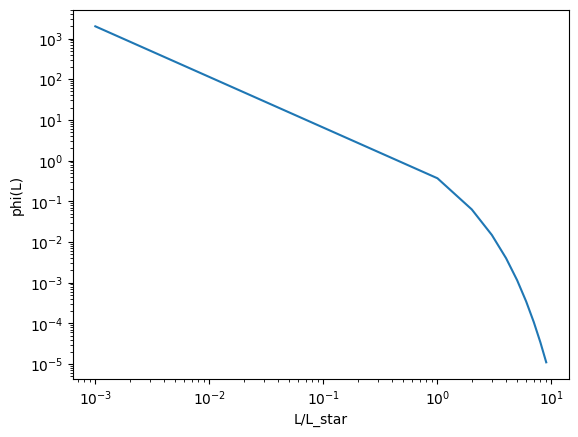

In [59]:
L_test = np.arange(1, 10000, 1000)
#L_test = np.logspace(1, 10000, 1000)
phi_test = proba_schechter_lum(L_test, 1000, -1.1)
L_ratio = L_test/1000
plt.plot(L_ratio, phi_test)
plt.yscale('log')
plt.xscale('log')
plt.xlabel('L/L_star')
plt.ylabel('phi(L)');

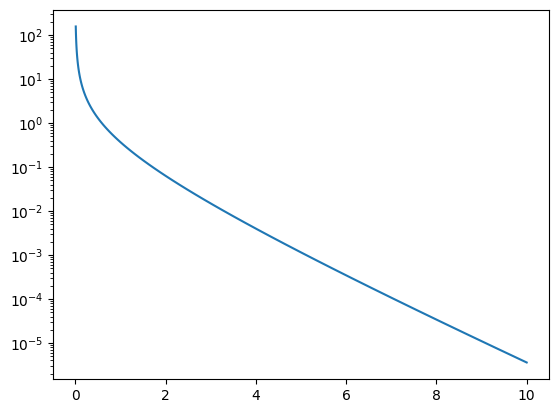

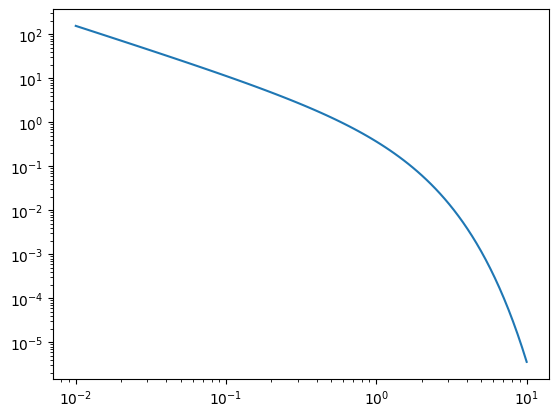

In [40]:
x=np.logspace(-2,1,100)
y=np.power(x,-1.1)*np.exp(-x)
plt.semilogy(x,y)
plt.figure()
plt.loglog(x,y);

Number of rejects = 74642


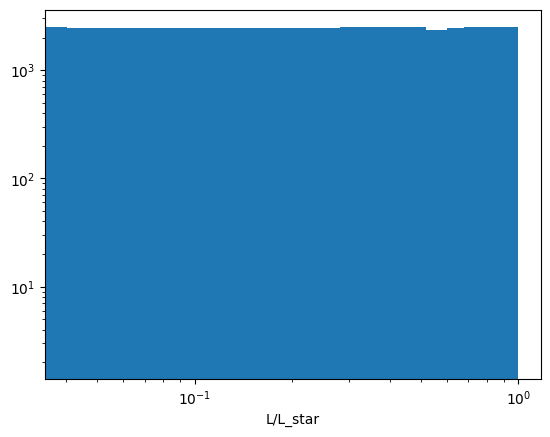

In [66]:
L = generate_schechter_lum(npix, L_star=1e10, alpha=-1.001, L_min=1e7, L_max=1e11, phi_star=1)
get_hist(np.log10(L/1e10), xlabel='L/L_star', bins=50)
plt.yscale('log')
plt.xscale('log');

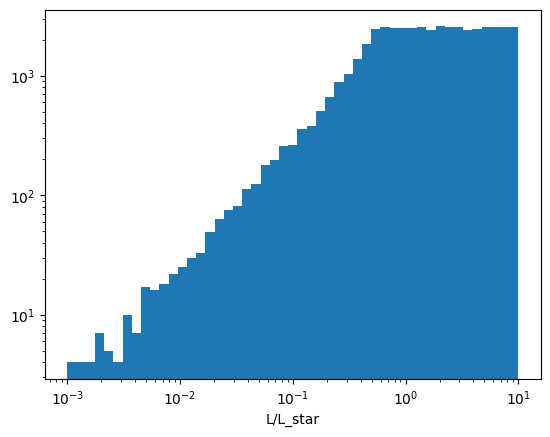

In [67]:
bins = np.logspace(np.log10(np.min(L/1e10)), np.log10(np.max(L/1e10)), 50)
get_hist(L/1e10, xlabel='L/L_star', bins=bins)
plt.yscale('log')
plt.xscale('log');

#### z, m, M, L, dL_mpc:

Number of rejects = 124478


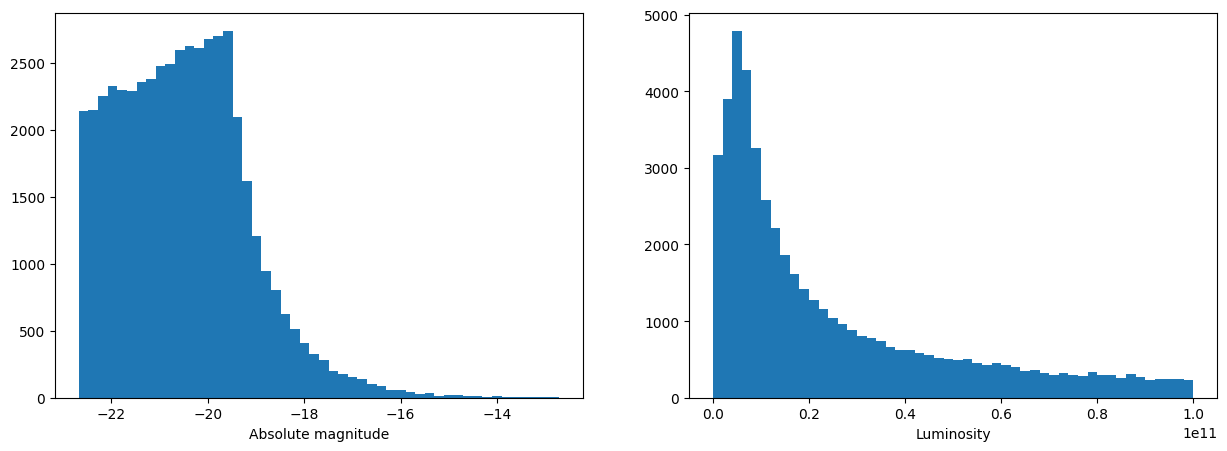

In [48]:
z, m, M, L, dL_mpc = generate_lumMag(npix)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
get_hist(M, xlabel='Absolute magnitude', bins=50, figax=(fig, ax[0]))
get_hist(L, xlabel='Luminosity', bins=50, figax=(fig, ax[1]));

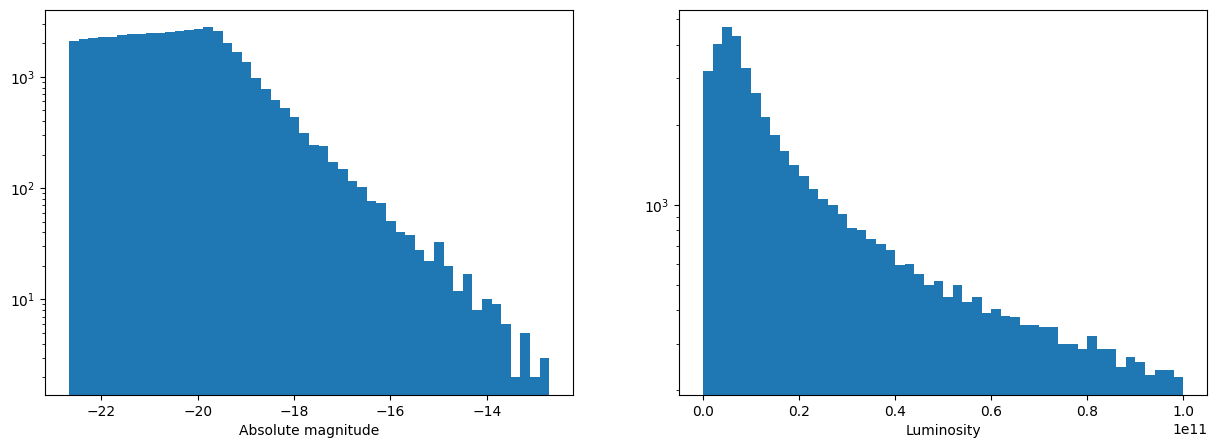

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
get_hist(M, xlabel='Absolute magnitude', bins=50, figax=(fig, ax[0]))
get_hist(L, xlabel='Luminosity', bins=50, figax=(fig, ax[1]))
ax[0].set_yscale('log')
ax[1].set_yscale('log');

### Log-log space:

/tmp/ipykernel_9888/2805202486.py:48: RuntimeWarning: divide by zero encountered in scalar divide
  if p_test < np.power(10**x_cand, alpha+1)/proba_schechter_lumLog(x_cand, alpha):


Number of rejects = 0


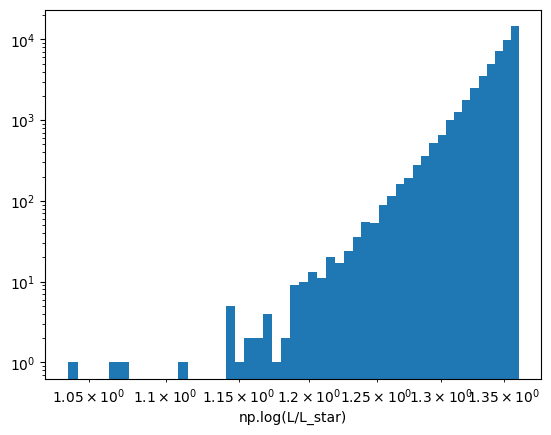

In [70]:
def proba_schechter_lumLog(x, alpha):
    """x = ln(L/L*)"""
    return (10**x)**(alpha + 1) * np.exp(-10**x)


def sample_truncated_power_lawLog(alpha, xmin, xmax, size=None):
    """
    Sample from a truncated power-law distribution p(x) ∝ (10^x)^alpha
    for xmin <= x <= xmax, with alpha < -1.

    Parameters:
        alpha (float): exponent (must be < -1)
        xmin (float): lower bound (> 0)
        xmax (float): upper bound (> xmin)
        size (int): number of samples

    Returns:
        numpy array of samples
    """
    if alpha == -1:
        raise ValueError("alpha = -1 requires a different (logarithmic) treatment")

    # Generate uniform random numbers
    u = np.random.uniform(0, 1, size)

    # Inverse CDF
    exponent = alpha + 1
    xmin_exp = (10**xmin) ** exponent
    xmax_exp = (10**xmax) ** exponent

    samples = (u * (xmax_exp - xmin_exp) + xmin_exp) ** (1 / exponent)

    return np.log(samples)


def generate_schechter_lumLog(n_samples, alpha, x_min, x_max):
    """
    Tire log10(L/L*) suivant Schechter.
    x = log10(L/L*)
    """
    samples = []
    reject = 0 #to count the number of rejects
    
    while len(samples) < n_samples:
        x_cand = sample_truncated_power_lawLog(alpha+1, x_min, x_max)
        p_test = np.random.uniform(0, np.power(10**x_cand, alpha+1))
        
        if p_test < np.power(10**x_cand, alpha+1)/proba_schechter_lumLog(x_cand, alpha):
            samples.append(x_cand)
        else: reject += 1
    print('Number of rejects =', reject) 
    return np.array(samples)


x = generate_schechter_lumLog(npix, alpha=-1.001, x_min=1e-3, x_max=10)
get_hist(np.log10(x), xlabel='np.log(L/L_star)', bins=50)
plt.yscale('log')
plt.xscale('log');